# Sign Language Representation Learning

This project explores representation learning techniques on the Sign Language MNIST dataset using autoencoders and variational autoencoders (VAEs).

The goal is to study latent representations, image reconstruction, clustering behaviour and simple image generation using deep learning methods.

# Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from sklearn.decomposition import PCA

In [2]:
train_df = pd.read_csv("../data/sign_mnist_train.csv")
test_df = pd.read_csv("../data/sign_mnist_test.csv")

print(train_df.shape)
print(test_df.shape)
train_df.head()

(27455, 785)
(7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
X_train = train_df.drop("label", axis=1).values.astype("float32")
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values.astype("float32")
y_test = test_df["label"].values

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(27455, 784)
(27455,)
(7172, 784)
(7172,)


In [4]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 255.0
0.0 255.0


In [5]:
# Normalize pixel values to the range [0,1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0


In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(27455, 28, 28, 1)
(7172, 28, 28, 1)


 Display a sample image after preprocessing

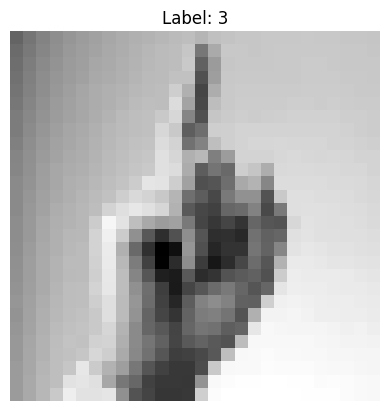

In [7]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [8]:
def build_autoencoder(latent_dim):

    encoder_input = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(encoder_input)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Flatten()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)

    latent = layers.Dense(latent_dim, name="latent_space")(x)

    encoder = Model(encoder_input, latent, name=f"encoder_M{latent_dim}")

    decoder_input = layers.Input(shape=(latent_dim,))

    x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
    x = layers.Reshape((7, 7, 64))(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)

    decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    decoder = Model(decoder_input, decoder_output, name=f"decoder_M{latent_dim}")

    autoencoder_output = decoder(encoder(encoder_input))
    autoencoder = Model(encoder_input, autoencoder_output, name=f"autoencoder_M{latent_dim}")

    autoencoder.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return encoder, decoder, autoencoder

In [9]:
print("Before training:")
print("X_train min/max:", X_train.min(), X_train.max())
print("X_test min/max:", X_test.min(), X_test.max())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Before training:
X_train min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (27455, 28, 28, 1)
X_test shape: (7172, 28, 28, 1)


In [10]:
encoder_2, decoder_2, autoencoder_2 = build_autoencoder(2)

history_2 = autoencoder_2.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, X_test)
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - loss: 0.6398 - val_loss: 0.6239
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.6257 - val_loss: 0.6189
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 0.6217 - val_loss: 0.6177
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - loss: 0.6205 - val_loss: 0.6165
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.6197 - val_loss: 0.6168
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.6187 - val_loss: 0.6154
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.6177 - val_loss: 0.6155
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - loss: 0.6173 - val_loss: 0.6144
Epoch 9/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - loss: 0.6166 - val_loss: 0.6141
Epoch 10/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - loss: 0.6162 - val_loss: 0.6135
Epoch 11/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.6156 - val_loss: 0.6136
Epoch 12/20
215/215 ━

In [11]:
encoder_10, decoder_10, autoencoder_10 = build_autoencoder(10)

history_10 = autoencoder_10.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, X_test)
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 29s 119ms/step - loss: 0.6363 - val_loss: 0.6190
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - loss: 0.6184 - val_loss: 0.6109
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.6067 - val_loss: 0.6006
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.6018 - val_loss: 0.5980
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.5989 - val_loss: 0.5977
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 65s 305ms/step - loss: 0.5968 - val_loss: 0.5950
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - loss: 0.5955 - val_loss: 0.5945
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - loss: 0.5945 - val_loss: 0.5940
Epoch 9/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.5936 - val_loss: 0.5943
Epoch 10/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.5927 - val_loss: 0.5934
Epoch 11/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - loss: 0.5922 - val_loss: 0.5929
Epoch 12/20
215/215 ━━━━━━

In [12]:
encoder_50, decoder_50, autoencoder_50 = build_autoencoder(50)

history_50 = autoencoder_50.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, X_test)
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - loss: 0.6354 - val_loss: 0.6141
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.6103 - val_loss: 0.5995
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - loss: 0.5994 - val_loss: 0.5941
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.5951 - val_loss: 0.5916
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 27s 126ms/step - loss: 0.5929 - val_loss: 0.5905
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - loss: 0.5915 - val_loss: 0.5902
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.5904 - val_loss: 0.5893
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - loss: 0.5895 - val_loss: 0.5891
Epoch 9/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.5889 - val_loss: 0.5886
Epoch 10/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.5883 - val_loss: 0.5885
Epoch 11/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.5878 - val_loss: 0.5882
Epoch 12/20
215/215 ━━━━━

In [13]:
reconstructed_2 = autoencoder_2.predict(X_test[:10])
reconstructed_10 = autoencoder_10.predict(X_test[:10])
reconstructed_50 = autoencoder_50.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


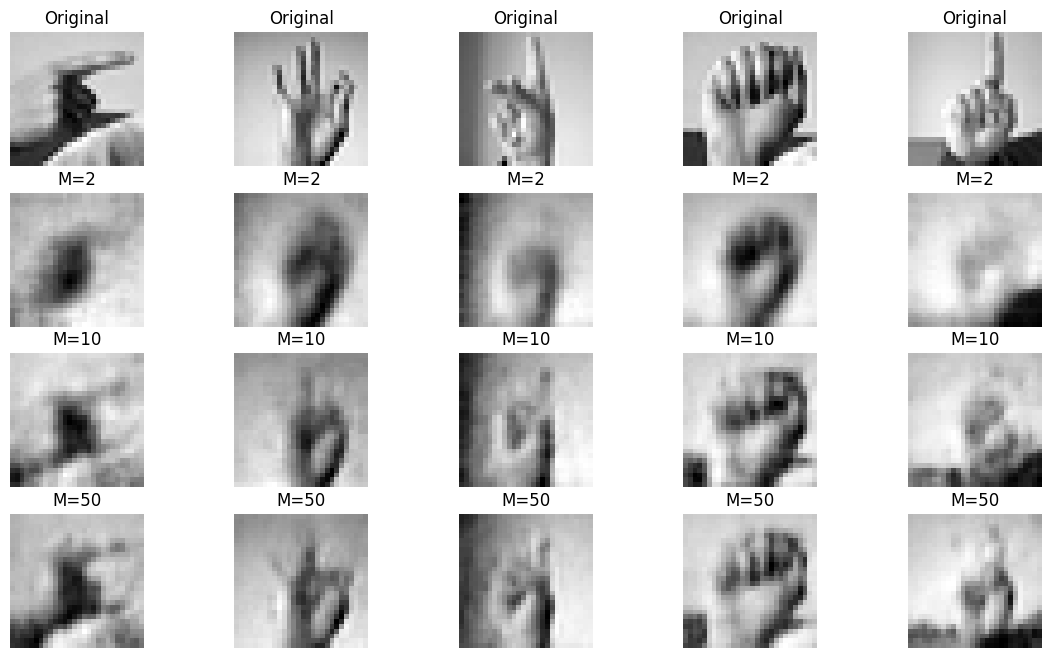

In [14]:
n = 5

plt.figure(figsize=(14, 8))

for i in range(n):

    plt.subplot(4, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4, n, i + 1 + n)
    plt.imshow(reconstructed_2[i].reshape(28, 28), cmap="gray")
    plt.title("M=2")
    plt.axis("off")

    plt.subplot(4, n, i + 1 + 2*n)
    plt.imshow(reconstructed_10[i].reshape(28, 28), cmap="gray")
    plt.title("M=10")
    plt.axis("off")

    plt.subplot(4, n, i + 1 + 3*n)
    plt.imshow(reconstructed_50[i].reshape(28, 28), cmap="gray")
    plt.title("M=50")
    plt.axis("off")

plt.show()

Larger latent dimensions preserve more visual information and produce clearer reconstructions. 

The M=2 latent space leads to blurry outputs due to heavy compression, while M=50 retains significantly more image detail.

In [15]:

Z_train_2 = encoder_2.predict(X_train)
Z_test_2 = encoder_2.predict(X_test)

Z_train_10 = encoder_10.predict(X_train)
Z_test_10 = encoder_10.predict(X_test)

Z_train_50 = encoder_50.predict(X_train)
Z_test_50 = encoder_50.predict(X_test)

print("Latent representations created.")

858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Latent representations created.


## Classification using latent representations

To evaluate the quality of the learned latent representations, an SVM classifier with RBF kernel is applied on the latent vectors produced by the autoencoders.

The RBF kernel was selected because the latent representations are not necessarily linearly separable. A small amount of hyperparameter experimentation was performed using different values of C and gamma. The final configuration (C=1, gamma="scale") provided stable performance and good generalization on the validation data.

In [16]:
# Check latent representation dimensions

print("M=2:", Z_train_2.shape, Z_test_2.shape)
print("M=10:", Z_train_10.shape, Z_test_10.shape)
print("M=50:", Z_train_50.shape, Z_test_50.shape)

M=2: (27455, 2) (7172, 2)
M=10: (27455, 10) (7172, 10)
M=50: (27455, 50) (7172, 50)


In [17]:
# Function for SVM training and evaluation
def evaluate_svm(X_train_data, X_test_data, y_train, y_test):

    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1, gamma="scale"))
    ])

    svm_model.fit(X_train_data, y_train)

    y_pred = svm_model.predict(X_test_data)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    return accuracy, precision, recall, f1

In [18]:

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

baseline_acc, baseline_prec, baseline_rec, baseline_f1 = evaluate_svm(
    X_train_flat,
    X_test_flat,
    y_train,
    y_test
)

print("Baseline - Original pixels")
print("Accuracy:", baseline_acc)
print("Precision:", baseline_prec)
print("Recall:", baseline_rec)
print("F1-score:", baseline_f1)

Baseline - Original pixels
Accuracy: 0.8489960959286112
Precision: 0.8371491909091059
Recall: 0.8359187372729857
F1-score: 0.8318809306102986


In [19]:

acc_2, prec_2, rec_2, f1_2 = evaluate_svm(
    Z_train_2,
    Z_test_2,
    y_train,
    y_test
)

print("Results for M=2")
print("Accuracy:", acc_2)
print("Precision:", prec_2)
print("Recall:", rec_2)
print("F1-score:", f1_2)

Results for M=2
Accuracy: 0.1986893474623536
Precision: 0.23694800930414303
Recall: 0.19995559606585603
F1-score: 0.16687540673962473


In [20]:

acc_10, prec_10, rec_10, f1_10 = evaluate_svm(
    Z_train_10,
    Z_test_10,
    y_train,
    y_test
)

print("Results for M=10")
print("Accuracy:", acc_10)
print("Precision:", prec_10)
print("Recall:", rec_10)
print("F1-score:", f1_10)

Results for M=10
Accuracy: 0.7700780814277747
Precision: 0.767956442014528
Recall: 0.7641069770886467
F1-score: 0.7625035408612857


In [21]:

acc_50, prec_50, rec_50, f1_50 = evaluate_svm(
    Z_train_50,
    Z_test_50,
    y_train,
    y_test
)

print("Results for M=50")
print("Accuracy:", acc_50)
print("Precision:", prec_50)
print("Recall:", rec_50)
print("F1-score:", f1_50)

Results for M=50
Accuracy: 0.8778583379810374
Precision: 0.8680558278958599
Recall: 0.8752876755079454
F1-score: 0.8644808446932606


In [22]:

classification_results = pd.DataFrame({
    "Representation": [
        "Original pixels",
        "AE M=2",
        "AE M=10",
        "AE M=50"
    ],
    "Accuracy": [
        baseline_acc,
        acc_2,
        acc_10,
        acc_50
    ],
    "Precision": [
        baseline_prec,
        prec_2,
        prec_10,
        prec_50
    ],
    "Recall": [
        baseline_rec,
        rec_2,
        rec_10,
        rec_50
    ],
    "F1-score": [
        baseline_f1,
        f1_2,
        f1_10,
        f1_50
    ]
})

classification_results

,Representation,Accuracy,Precision,Recall,F1-score
0,Original pixels,0.848996,0.837149,0.835919,0.831881
1,AE M=2,0.198689,0.236948,0.199956,0.166875
2,AE M=10,0.770078,0.767956,0.764107,0.762504
3,AE M=50,0.877858,0.868056,0.875288,0.864481


The latent dimension strongly affects classification performance.
Very small latent spaces (M=2) lose important information due to heavy compression, leading to low classification accuracy. As the latent dimension increases, the learned representations become more informative and classification performance improves significantly.
The M=50 latent representation achieved the best overall performance, outperforming the baseline model trained directly on image pixels.

In [23]:
# Check latent representation dimensions
# used for clustering experiments

print("M=2:", Z_train_2.shape)
print("M=10:", Z_train_10.shape)
print("M=50:", Z_train_50.shape)

M=2: (27455, 2)
M=10: (27455, 10)
M=50: (27455, 50)


Clustering algorithms are applied directly on the latent vectors produced by the encoder in order to study the structure of the learned feature space.

In [24]:
# K-means clustering for M=2
# Evaluate silhouette score for K values from 2 to 30
k_values = range(2, 31)

scores_2 = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )
    
    labels = kmeans.fit_predict(Z_train_2)
    score = silhouette_score(Z_train_2, labels)
    
    scores_2.append(score)
    
    print("M=2 | K =", k, "| Silhouette Score =", score)

M=2 | K = 2 | Silhouette Score = 0.3419715166091919
M=2 | K = 3 | Silhouette Score = 0.3255787789821625
M=2 | K = 4 | Silhouette Score = 0.3316957652568817
M=2 | K = 5 | Silhouette Score = 0.36324283480644226
M=2 | K = 6 | Silhouette Score = 0.38266319036483765
M=2 | K = 7 | Silhouette Score = 0.35213321447372437
M=2 | K = 8 | Silhouette Score = 0.35488954186439514
M=2 | K = 9 | Silhouette Score = 0.3635194003582001
M=2 | K = 10 | Silhouette Score = 0.35833466053009033
M=2 | K = 11 | Silhouette Score = 0.36544403433799744
M=2 | K = 12 | Silhouette Score = 0.3514527380466461
M=2 | K = 13 | Silhouette Score = 0.35131949186325073
M=2 | K = 14 | Silhouette Score = 0.34530261158943176
M=2 | K = 15 | Silhouette Score = 0.34511110186576843
M=2 | K = 16 | Silhouette Score = 0.35028526186943054
M=2 | K = 17 | Silhouette Score = 0.3499703109264374
M=2 | K = 18 | Silhouette Score = 0.3414212465286255
M=2 | K = 19 | Silhouette Score = 0.3487033247947693
M=2 | K = 20 | Silhouette Score = 0.34568154

In [25]:
# K-means clustering for M=10
# Evaluate silhouette score for K values from 2 to 30

scores_10 = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )
    
    labels = kmeans.fit_predict(Z_train_10)
    score = silhouette_score(Z_train_10, labels)
    
    scores_10.append(score)
    
    print("M=10 | K =", k, "| Silhouette Score =", score)

M=10 | K = 2 | Silhouette Score = 0.1516084223985672
M=10 | K = 3 | Silhouette Score = 0.15584005415439606
M=10 | K = 4 | Silhouette Score = 0.13294333219528198
M=10 | K = 5 | Silhouette Score = 0.1326872855424881
M=10 | K = 6 | Silhouette Score = 0.1361788958311081
M=10 | K = 7 | Silhouette Score = 0.13933511078357697
M=10 | K = 8 | Silhouette Score = 0.1309385746717453
M=10 | K = 9 | Silhouette Score = 0.13607637584209442
M=10 | K = 10 | Silhouette Score = 0.1329856514930725
M=10 | K = 11 | Silhouette Score = 0.12884661555290222
M=10 | K = 12 | Silhouette Score = 0.13608916103839874
M=10 | K = 13 | Silhouette Score = 0.13267792761325836
M=10 | K = 14 | Silhouette Score = 0.12896773219108582
M=10 | K = 15 | Silhouette Score = 0.12308252602815628
M=10 | K = 16 | Silhouette Score = 0.13391633331775665
M=10 | K = 17 | Silhouette Score = 0.1363004893064499
M=10 | K = 18 | Silhouette Score = 0.1427178978919983
M=10 | K = 19 | Silhouette Score = 0.13843634724617004
M=10 | K = 20 | Silhouett

In [26]:
# K-means clustering for M=50
# Evaluate silhouette score for K values from 2 to 30

scores_50 = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )
    
    labels = kmeans.fit_predict(Z_train_50)
    score = silhouette_score(Z_train_50, labels)
    
    scores_50.append(score)
    
    print("M=50 | K =", k, "| Silhouette Score =", score)

M=50 | K = 2 | Silhouette Score = 0.15942905843257904
M=50 | K = 3 | Silhouette Score = 0.11938884854316711
M=50 | K = 4 | Silhouette Score = 0.10372933000326157
M=50 | K = 5 | Silhouette Score = 0.10444022715091705
M=50 | K = 6 | Silhouette Score = 0.10874903202056885
M=50 | K = 7 | Silhouette Score = 0.10590406507253647
M=50 | K = 8 | Silhouette Score = 0.10079934448003769
M=50 | K = 9 | Silhouette Score = 0.10389155894517899
M=50 | K = 10 | Silhouette Score = 0.10550399869680405
M=50 | K = 11 | Silhouette Score = 0.1058310866355896
M=50 | K = 12 | Silhouette Score = 0.10846050828695297
M=50 | K = 13 | Silhouette Score = 0.09827976673841476
M=50 | K = 14 | Silhouette Score = 0.10213582962751389
M=50 | K = 15 | Silhouette Score = 0.10530375689268112
M=50 | K = 16 | Silhouette Score = 0.1154266819357872
M=50 | K = 17 | Silhouette Score = 0.09485829621553421
M=50 | K = 18 | Silhouette Score = 0.10525355488061905
M=50 | K = 19 | Silhouette Score = 0.10955408960580826
M=50 | K = 20 | Silh

In [27]:
# Find the best K value for each latent space

best_index_2 = np.argmax(scores_2)
best_k_2 = list(k_values)[best_index_2]
best_score_2 = scores_2[best_index_2]

best_index_10 = np.argmax(scores_10)
best_k_10 = list(k_values)[best_index_10]
best_score_10 = scores_10[best_index_10]

best_index_50 = np.argmax(scores_50)
best_k_50 = list(k_values)[best_index_50]
best_score_50 = scores_50[best_index_50]

print("Best K* for M=2:", best_k_2, "| Silhouette:", best_score_2)
print("Best K* for M=10:", best_k_10, "| Silhouette:", best_score_10)
print("Best K* for M=50:", best_k_50, "| Silhouette:", best_score_50)

Best K* for M=2: 6 | Silhouette: 0.38266319036483765
Best K* for M=10: 3 | Silhouette: 0.15584005415439606
Best K* for M=50: 2 | Silhouette: 0.15942905843257904


In [28]:
# Run K-means again using the optimal number of clusters
kmeans_2 = KMeans(n_clusters=best_k_2, n_init=20, random_state=42)
kmeans_labels_2 = kmeans_2.fit_predict(Z_train_2)
final_kmeans_score_2 = silhouette_score(Z_train_2, kmeans_labels_2)

kmeans_10 = KMeans(n_clusters=best_k_10, n_init=20, random_state=42)
kmeans_labels_10 = kmeans_10.fit_predict(Z_train_10)
final_kmeans_score_10 = silhouette_score(Z_train_10, kmeans_labels_10)

kmeans_50 = KMeans(n_clusters=best_k_50, n_init=20, random_state=42)
kmeans_labels_50 = kmeans_50.fit_predict(Z_train_50)
final_kmeans_score_50 = silhouette_score(Z_train_50, kmeans_labels_50)

print("Final K-means M=2:", final_kmeans_score_2)
print("Final K-means M=10:", final_kmeans_score_10)
print("Final K-means M=50:", final_kmeans_score_50)

Final K-means M=2: 0.38266319036483765
Final K-means M=10: 0.15584005415439606
Final K-means M=50: 0.15942905843257904


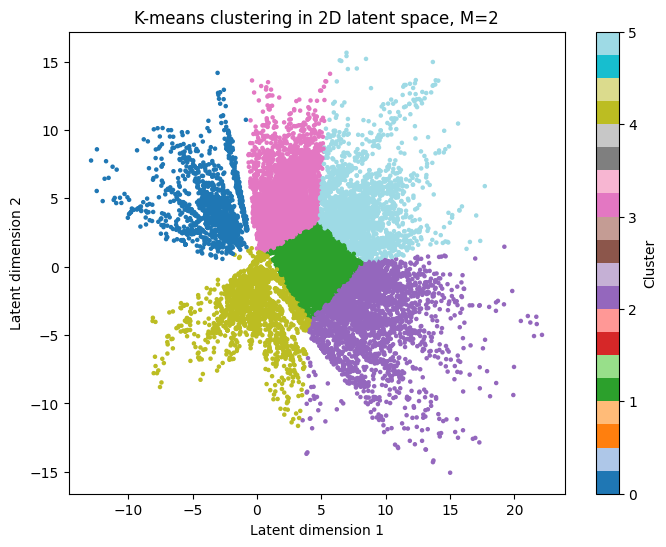

In [29]:
# Visualize K-means clusters in the 2D latent space

plt.figure(figsize=(8, 6))

plt.scatter(
    Z_train_2[:, 0],
    Z_train_2[:, 1],
    c=kmeans_labels_2,
    s=5,
    cmap="tab20"
)

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("K-means clustering in 2D latent space, M=2")
plt.colorbar(label="Cluster")
plt.show()

Several groups of samples are relatively well separated in the two-dimensional latent space, although some overlap between clusters is still present.

This observation is consistent with the silhouette score obtained for M=2.

The VAE models are trained using the preprocessed image data from the previous section (normalized and reshaped images).

In [30]:
latent_dim = 2
batch_size = 128
epochs = 20
learning_rate = 0.001
# Basic VAE training parameters
# The latent space dimension is set to 2

In [31]:
class Sampling(layers.Layer):
   
    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        return z

The VAE encoder produces the parameters of a Gaussian distribution instead of a single latent vector.

Using the reparameterization trick, latent vectors are sampled from this distribution:

z = z_mean + exp(0.5 * z_log_var) * epsilon

where epsilon is random Gaussian noise sampled from N(0, I).

In [32]:
# VAE encoder

encoder_inputs = layers.Input(
    shape=(28, 28, 1)
)

x = layers.Conv2D(
    32,
    kernel_size=3,
    activation="relu",
    padding="same"
)(encoder_inputs)

x = layers.MaxPooling2D(
    pool_size=2,
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    kernel_size=3,
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    pool_size=2,
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dense(
    32,
    activation="relu"
)(x)

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

z = Sampling()([
    z_mean,
    z_log_var
])

vae_encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="vae_encoder"
)

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 28, 28, 32)        │             320 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 14, 14, 32)        │               0 │ conv2d_9[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 14, 14, 64)        │          18,496 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 7, 7, 64)          │               0 │ conv2d_10[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 3136)              │               0 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 128)               │         401,536 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 64)                │           8,256 │ dense_12[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 32)                │           2,080 │ dense_13[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              66 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              66 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling (Sampling)           │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 430,820 (1.64 MB)

 Trainable params: 430,820 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

The encoder gradually reduces the spatial dimensions of the input image using convolution and pooling layers.

The dense layers further compress the information until the final two-dimensional latent representation is produced.

In [33]:
# VAE decoder
# Reconstruct images from latent vectors

decoder_inputs = layers.Input(
    shape=(latent_dim,)
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(decoder_inputs)

x = layers.Reshape(
    (7, 7, 64)
)(x)

x = layers.Conv2DTranspose(
    64,
    kernel_size=3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    kernel_size=3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

decoder_outputs = layers.Conv2D(
    1,
    kernel_size=3,
    activation="sigmoid",
    padding="same"
)(x)

vae_decoder = Model(
    decoder_inputs,
    decoder_outputs,
    name="vae_decoder"
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 3136)                │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_3 (Reshape)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_6 (Conv2DTranspose) │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_7 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
class VAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

In [35]:
vae = VAE(
    vae_encoder,
    vae_decoder
)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )
)

history_vae = vae.fit(
    X_train,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - kl_loss: 1.4039 - loss: 507.5028 - reconstruction_loss: 506.0988
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - kl_loss: 1.8006 - loss: 499.1291 - reconstruction_loss: 497.3286
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - kl_loss: 1.7668 - loss: 498.7292 - reconstruction_loss: 496.9624
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - kl_loss: 1.8400 - loss: 498.2918 - reconstruction_loss: 496.4518
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - kl_loss: 2.9982 - loss: 494.3697 - reconstruction_loss: 491.3716
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - kl_loss: 3.2915 - loss: 492.1195 - reconstruction_loss: 488.8280
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - kl_loss: 3.4110 - loss: 491.5923 - reconstruction_loss: 488.1816
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - kl_loss: 3.5024 - loss: 491.2413 - reconstruction_loss: 487.7388
Epoch 9/20
215/215 ━━━━━

During training, both the total loss and reconstruction loss decrease gradually, indicating that the model learns increasingly better image reconstructions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step


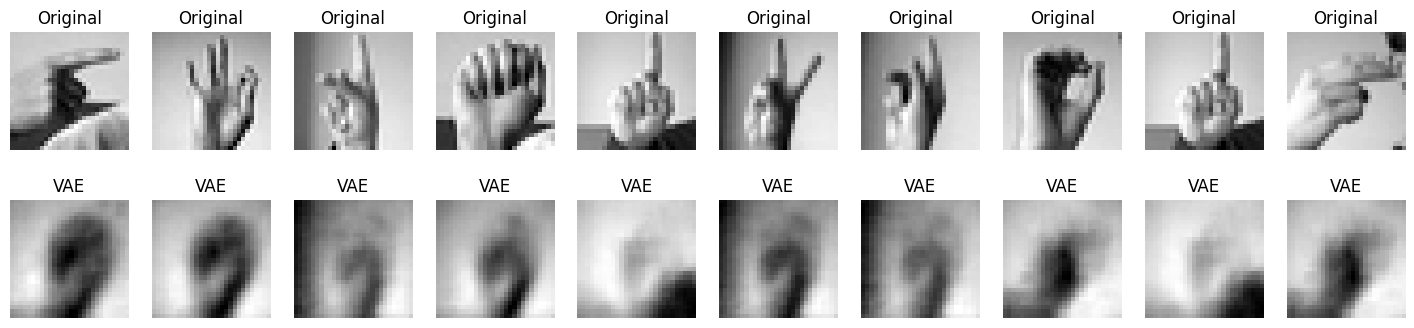

In [36]:

n = 10

test_images = X_test[:n]

reconstructed_images = vae.predict(
    test_images
)

plt.figure(figsize=(18, 4))

for i in range(n):

    # Αρχικές εικόνες
    plt.subplot(2, n, i + 1)

    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Ανακατασκευασμένες εικόνες
    plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        reconstructed_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("VAE")
    plt.axis("off")

plt.show()

The reconstructed images preserve the general structure of the original hand signs, although they appear blurrier due to the small latent dimension (M=2).

New sign language images are generated by sampling random latent vectors from a Gaussian distribution and passing them through the decoder.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


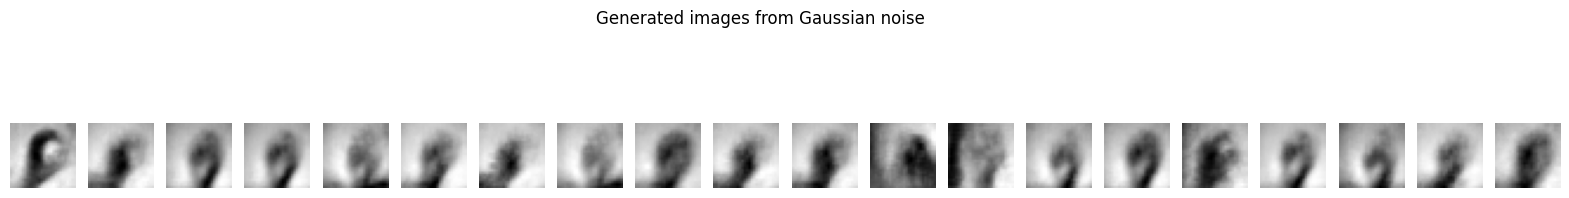

In [37]:

n = 20

random_latent_vectors = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(n, latent_dim)
)

generated_images = vae_decoder.predict(
    random_latent_vectors
)

plt.figure(figsize=(20, 3))

for i in range(n):

    plt.subplot(1, n, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Generated images from Gaussian noise")

plt.show()

The VAE is capable of generating new images that resemble ASL hand signs, although the generated samples remain blurry due to the low-dimensional latent space.

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


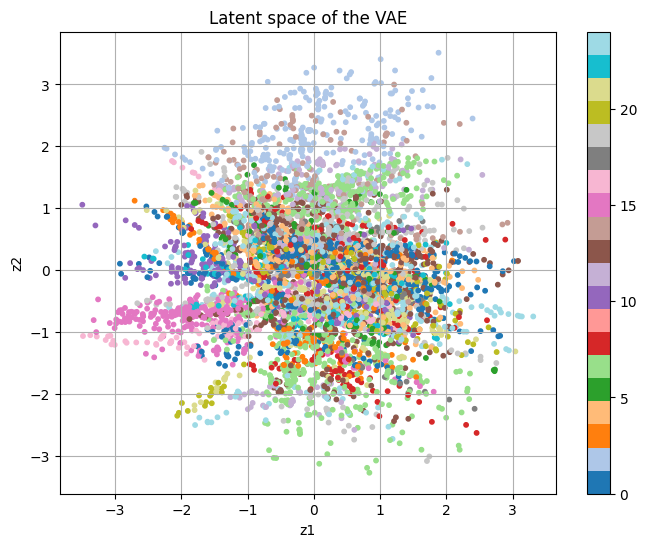

In [38]:

z_mean_test, z_log_var_test, z_test = vae_encoder.predict(
    X_test
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab20",
    s=10
)

plt.colorbar(scatter)

plt.xlabel("z1")
plt.ylabel("z2")

plt.title("Latent space of the VAE")

plt.grid(True)

plt.show()

The latent space visualization shows partial grouping of similar samples, although overlap between classes is still present.

This behaviour is expected because the model is trained without labels and compresses all image categories into only two latent dimensions.

In [39]:
# Convert labels to consecutive integer values
# for one-hot encoding

le = LabelEncoder()

y_train_idx = le.fit_transform(y_train)
y_test_idx = le.transform(y_test)
# Convert labels to one-hot vectors

y_train_onehot = to_categorical(y_train_idx)
y_test_onehot = to_categorical(y_test_idx)

print("Train one-hot shape:", y_train_onehot.shape)
print("Test one-hot shape:", y_test_onehot.shape)

Train one-hot shape: (27455, 24)
Test one-hot shape: (7172, 24)


In [40]:
# cVAE encoder

image_input = layers.Input(
    shape=(28, 28, 1),
    name="image_input"
)

label_input = layers.Input(
    shape=(24,),
    name="label_input"
)

x = layers.Conv2D(
    32,
    kernel_size=3,
    activation="relu",
    padding="same"
)(image_input)

x = layers.MaxPooling2D(
    pool_size=2,
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    kernel_size=3,
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    pool_size=2,
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Concatenate()([
    x,
    label_input
])

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dense(
    32,
    activation="relu"
)(x)

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

z = Sampling()([
    z_mean,
    z_log_var
])

cvae_encoder = Model(
    inputs=[image_input, label_input],
    outputs=[z_mean, z_log_var, z],
    name="cvae_encoder"
)

cvae_encoder.summary()

Model: "cvae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 28, 28, 32)        │             320 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 14, 14, 32)        │               0 │ conv2d_12[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 14, 14, 64)        │          18,496 │ max_pooling2d_8[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 7, 7, 64)          │               0 │ conv2d_13[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 3136)              │               0 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 128)               │         401,536 │ flatten_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ label_input (InputLayer)      │ (None, 24)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 152)               │               0 │ dense_16[0][0],            │
│                               │                           │                 │ label_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 64)                │           9,792 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_18 (Dense)              │ (None, 32)                │           2,080 │ dense_17[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              66 │ dense_18[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              66 │ dense_18[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling_1 (Sampling)         │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 432,356 (1.65 MB)

 Trainable params: 432,356 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

The conditional VAE (cVAE) receives both the image and its class label as input, allowing the latent space to incorporate label information during training.

In [41]:
# cVAE decoder

latent_inputs = layers.Input(
    shape=(latent_dim,),
    name="latent_input"
)

label_inputs = layers.Input(
    shape=(24,),
    name="decoder_label_input"
)

x = layers.Concatenate()([
    latent_inputs,
    label_inputs
])

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(x)

x = layers.Reshape(
    (7, 7, 64)
)(x)

x = layers.Conv2DTranspose(
    64,
    kernel_size=3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    kernel_size=3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

decoder_outputs = layers.Conv2D(
    1,
    kernel_size=3,
    activation="sigmoid",
    padding="same"
)(x)

cvae_decoder = Model(
    [latent_inputs, label_inputs],
    decoder_outputs,
    name="cvae_decoder"
)

cvae_decoder.summary()

Model: "cvae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)     │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_label_input           │ (None, 24)                │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 26)                │               0 │ latent_input[0][0],        │
│                               │                           │                 │ decoder_label_input[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 3136)              │          84,672 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_4 (Reshape)           │ (None, 7, 7, 64)          │               0 │ dense_19[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_8            │ (None, 14, 14, 64)        │          36,928 │ reshape_4[0][0]            │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_9            │ (None, 28, 28, 32)        │          18,464 │ conv2d_transpose_8[0][0]   │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_14 (Conv2D)            │ (None, 28, 28, 1)         │             289 │ conv2d_transpose_9[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 140,353 (548.25 KB)

 Trainable params: 140,353 (548.25 KB)

 Non-trainable params: 0 (0.00 B)

The cVAE decoder receives both the latent vector and the one-hot encoded class label, allowing the generated images to be conditioned on a specific category.

In [42]:
class CVAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

   
        images, labels = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                [images, labels]
            )

            reconstruction = self.decoder(
                [z, labels]
            )

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        images,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):

        images, labels = inputs

        z_mean, z_log_var, z = self.encoder(
            [images, labels]
        )

        reconstruction = self.decoder(
            [z, labels]
        )

        return reconstruction

The conditional VAE is trained using both image data and one-hot encoded labels.

In [43]:
cvae = CVAE(
    cvae_encoder,
    cvae_decoder
)

cvae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )
)

history_cvae = cvae.fit(
    (X_train, y_train_onehot),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - kl_loss: 1.1633 - loss: 504.3922 - reconstruction_loss: 503.2289
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 2093s 10s/step - kl_loss: 1.7738 - loss: 493.0500 - reconstruction_loss: 491.2763
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - kl_loss: 2.6426 - loss: 489.3900 - reconstruction_loss: 486.7475
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - kl_loss: 3.1134 - loss: 485.6253 - reconstruction_loss: 482.5121
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - kl_loss: 3.3344 - loss: 483.6766 - reconstruction_loss: 480.3422
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - kl_loss: 3.4374 - loss: 482.8344 - reconstruction_loss: 479.3969
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - kl_loss: 3.5248 - loss: 482.2009 - reconstruction_loss: 478.6760
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - kl_loss: 3.6162 - loss: 481.6357 - reconstruction_loss: 478.0195
Epoch 9/20
215/215 ━━━━━━━━━

During training, both the total loss and reconstruction loss decrease gradually, indicating that the model learns improved image reconstructions while incorporating label information into the latent space.


Original images are compared with their cVAE reconstructions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


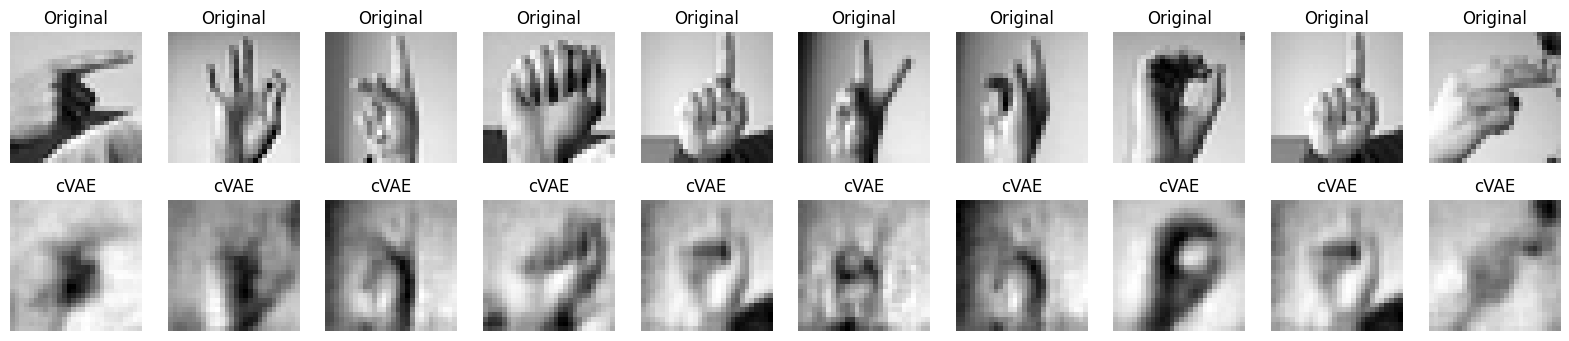

In [44]:
n = 10

test_images = X_test[:n]
test_labels = y_test_onehot[:n]


reconstructed_images = cvae.predict(
    [test_images, test_labels]
)

plt.figure(figsize=(20,4))

for i in range(n):

    
    plt.subplot(2, n, i + 1)

    plt.imshow(
        test_images[i].reshape(28,28),
        cmap="gray"
    )

    plt.title("Original")

    plt.axis("off")

    
    plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        reconstructed_images[i].reshape(28,28),
        cmap="gray"
    )

    plt.title("cVAE")

    plt.axis("off")

plt.show()

The cVAE reconstructions preserve the general structure of the original hand signs, although the generated images remain blurry due to the low-dimensional latent space.

The cVAE generates new images using random latent vectors together with selected class labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


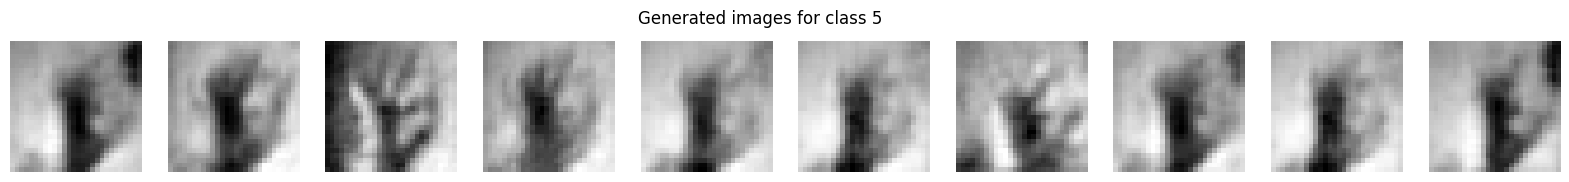

In [45]:
n = 10
num_classes = 24

random_latent_vectors = np.random.normal(
    size=(n, latent_dim)
)

selected_class = 5

labels = np.zeros((n, num_classes))

labels[:, selected_class] = 1

generated_images = cvae_decoder.predict(
    [random_latent_vectors, labels]
)

plt.figure(figsize=(20,2))

for i in range(n):

    plt.subplot(1, n, i + 1)

    plt.imshow(
        generated_images[i].reshape(28,28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    f"Generated images for class {selected_class}"
)

plt.show()

The generated images for the same class share several visual similarities, indicating that the cVAE has learned class-dependent latent representations.

The latent space of the cVAE is visualized using the test dataset.

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


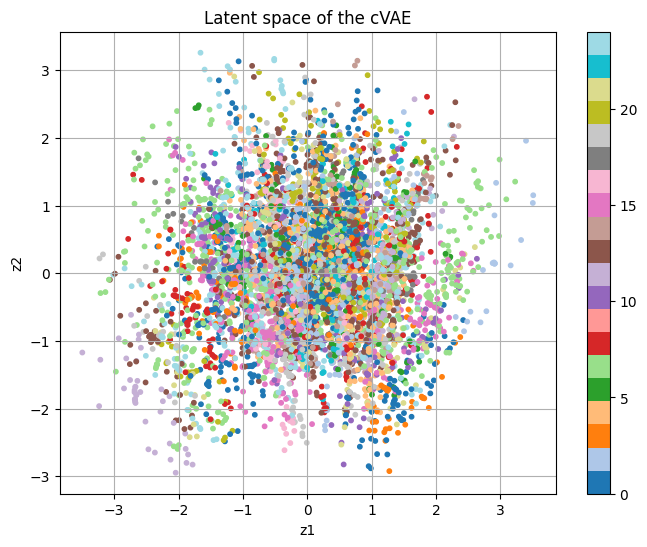

In [46]:

z_mean, _, _ = cvae_encoder.predict(
    [X_test, y_test_onehot]
)

plt.figure(figsize=(8,6))

plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    c=y_test,
    cmap="tab20",
    s=10
)

plt.colorbar()

plt.xlabel("z1")
plt.ylabel("z2")

plt.title("Latent space of the cVAE")

plt.grid(True)

plt.show()

The cVAE latent space shows partial grouping of samples, although overlap between classes is still present due to the low-dimensional representation.

Because label information is provided during training, the latent space focuses more on general image structure rather than strict class separation.

PCA is applied to the flattened images in order to compare a linear dimensionality reduction method with the learned latent spaces of the VAE and cVAE models.

In [47]:
# Flatten images into vectors
X_test_flat = X_test.reshape(
    X_test.shape[0],
    -1
)

print(X_test_flat.shape)

(7172, 784)


In [48]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_test_flat
)

print(X_pca.shape)

(7172, 2)


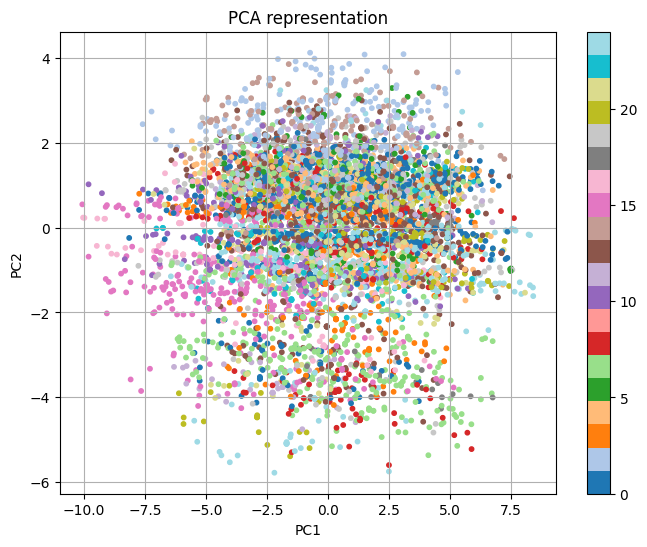

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_test,
    cmap="tab20",
    s=10
)

plt.colorbar()

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA representation")

plt.grid(True)

plt.show()

The PCA visualization shows significant overlap between classes, indicating that a simple linear projection is not sufficient to clearly separate the different hand sign categories.

In [50]:
# Extract latent representations from VAE, cVAE and PCA

vae_train_mean, _, _ = vae_encoder.predict(X_train)
vae_test_mean, _, _ = vae_encoder.predict(X_test)

cvae_train_mean, _, _ = cvae_encoder.predict([X_train, y_train_onehot])
cvae_test_mean, _, _ = cvae_encoder.predict([X_test, y_test_onehot])

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

pca = PCA(n_components=2)
pca_train = pca.fit_transform(X_train_flat)
pca_test = pca.transform(X_test_flat)

print("VAE:", vae_train_mean.shape, vae_test_mean.shape)
print("cVAE:", cvae_train_mean.shape, cvae_test_mean.shape)
print("PCA:", pca_train.shape, pca_test.shape)

858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
VAE: (27455, 2) (7172, 2)
cVAE: (27455, 2) (7172, 2)
PCA: (27455, 2) (7172, 2)


In [51]:
# Evaluate the learned representations using an RBF SVM classifier

vae_acc, vae_prec, vae_rec, vae_f1 = evaluate_svm(
    vae_train_mean,
    vae_test_mean,
    y_train,
    y_test
)

cvae_acc, cvae_prec, cvae_rec, cvae_f1 = evaluate_svm(
    cvae_train_mean,
    cvae_test_mean,
    y_train,
    y_test
)

pca_acc, pca_prec, pca_rec, pca_f1 = evaluate_svm(
    pca_train,
    pca_test,
    y_train,
    y_test
)

print("VAE accuracy:", vae_acc)
print("cVAE accuracy:", cvae_acc)
print("PCA accuracy:", pca_acc)

VAE accuracy: 0.19366982710540992
cVAE accuracy: 0.07863915225878416
PCA accuracy: 0.1079196876742889


In [52]:
b_classification_results = pd.DataFrame({
    "Method": [
        "VAE",
        "cVAE",
        "PCA"
    ],
    "Accuracy": [
        vae_acc,
        cvae_acc,
        pca_acc
    ],
    "Precision": [
        vae_prec,
        cvae_prec,
        pca_prec
    ],
    "Recall": [
        vae_rec,
        cvae_rec,
        pca_rec
    ],
    "F1-score": [
        vae_f1,
        cvae_f1,
        pca_f1
    ]
})

b_classification_results

,Method,Accuracy,Precision,Recall,F1-score
0,VAE,0.193670,0.170114,0.200345,0.142497
1,cVAE,0.078639,0.071128,0.081146,0.057964
2,PCA,0.107920,0.130097,0.118909,0.085746


# Final Comparison and Discussion

The comparison results show that the learned latent representations produced by the deep learning models preserve useful information for classification.

Among the evaluated methods, the VAE achieved the best classification performance. This suggests that the latent space learned by the VAE retains important structural information from the original images, allowing the SVM classifier to better separate the classes.

PCA achieved lower performance because it relies only on linear projections and cannot capture the complex non-linear structure of the image data. The PCA visualization also showed stronger overlap between classes.

The cVAE produced lower classification accuracy compared to the standard VAE. Since label information is directly provided during training, the cVAE latent space focuses more on general image structure and conditional image generation rather than strict class separation.

An important advantage of the cVAE is the ability to generate images conditioned on specific class labels. The generated samples for the same label shared similar visual characteristics, showing that the model learned class-dependent latent representations.

Overall, the experiments demonstrate how representation learning methods can extract meaningful low-dimensional features from image data and organize them into structured latent spaces.

# Conclusion

This project explored representation learning techniques on the Sign Language MNIST dataset using autoencoders, variational autoencoders (VAEs) and conditional variational autoencoders (cVAEs).

The experiments showed that deep learning models can learn compact latent representations that preserve useful information for classification, clustering and image generation tasks.

Overall, the project demonstrates how neural networks can automatically extract meaningful features directly from image data.